<div style="text-align:center; markdown=1">
<span style="font-size:12pt">Final Project</span><br>
<span style="font-size:14pt"><b>Perancangan Softsensor Deteksi Aktivitas Manusia Menggunakan Data Gyroscope dan Akselerometer dari Perangkat Mobile</b></span><br>
Menggunakan Random Forest dan KNeighbours Classifiers</div>

<span style="font-size:14pt"><b>Kelompok 11</b></span><br>
<span style="font-size:14pt">M. Nadhir Al Ghifary (22/503570/TK/55030)</span><br>
<span style="font-size:14pt">Natasya Aisyah Dini (22/503833/TK/55079)</span><br>
<span style="font-size:14pt">Melathi Andhara Putri (22/503582/TK/55033)</span><br>
<span style="font-size:14pt">Ahmad Fauzan Bakri (22/497813/TK/54577)</span><br>

___

### <span style="font-size:20pt"><b>#1: Dataset</b></span>

#### <b>A. Sumber Dataset</b>

Nahid, Abdullah-Al; Sikder, Niloy; Rafi, Ibrahim (2020), “KU-HAR: An Open Dataset for Human Activity Recognition”, Mendeley Data, V3, doi: 10.17632/45f952y38r.3

https://www.kaggle.com/datasets/arashnic/har-1

#### <b>B. Deskripsi Dataset</b>

<b> Tentang Dataset: </b>

Dataset KU-HAR adalah kumpulan data Human Activity Recognition (HAR) yang berisi informasi 18 aktivitas manusia yang direkam dari 90 partisipan menggunakan sensor akselerometer dan giroskop pada smartphone. Dataset ini terdiri dari 1945 data aktivitas mentah, 9185 subsample hasil ekstraksi, dan fitur domain frekuensi hasil DFT, seluruhnya diambil dengan sampling rate 100 Hz tanpa filtering. Aktivitas yang dicatat mencakup gerakan sederhana hingga kompleks, seperti berdiri diam, berlari, naik tangga, hingga bermain tenis meja.


<b> Jumlah Aktivitas: </b>

Terdapat 12 aktivitas (12 folder) yang terdiri dari
- <b> Stand➞ Standing still (1 min) </b>
- <b> Sit➞ Sitting still (1 min) </b>
- Talk-sit➞ Talking with hand movements while sitting (1 min)
- Talk-stand➞ Talking with hand movements while standing or walking(1 min)
- Stand-sit➞ Repeatedly standing up and sitting down (5 times)
- <b> Lay➞ Laying still (1 min) </b>
- Lay-stand➞ Repeatedly standing up and laying down (5 times)
- Pick➞ Picking up an object from the floor (10 times)
- Jump➞ Jumping repeatedly (10 times)
- Push-up➞ Performing full push-ups (5 times)
- Sit-up➞ Performing sit-ups (5 times)
- <b> Walk➞ Walking 20 meters (≈12 s) </b>
- Walk-backward➞ Walking backward for 20 meters (≈20 s)
- Walk-circle➞ Walking along a circular path (≈ 20 s)
- <b> Run➞ Running 20 meters (≈7 s) </b>
- Stair-up➞ Ascending on a set of stairs (≈1 min)
- Stair-down➞ Descending from a set of stairs (≈50 s)
- Table-tennis➞ Playing table tennis (1 min)



<b> Jumlah Data per Aktivitas: </b>

Setiap aktivitas, terdapat 90 partisipan yang melakukan setiap aktivitas dengan rincian
- 75 pria
- 15 wanita

Oleh karena itu, diperoleh setidaknya <b> 90 data per aktivitas </b>

#### <b>B. Perancangan Softsensor</b>

<b> Masalah yang Dapat Diselesaikan </b>

- Pemantauan aktivitas fisik secara real-time tanpa perangkat tambahan.
- Deteksi dini terhadap perubahan pola aktivitas yang dapat mengindikasikan gangguan kesehatan.
- Pemantauan aktivitas lansia atau pasien secara non-invasif dalam konteks perawatan jarak jauh.
- Identifikasi jenis aktivitas pengguna (seperti berjalan, duduk, berlari) hanya melalui smartphone.


<b> Variable Mentah </b>
- Elapsed Time : Waktu sejak pengukuran dimulai (sekon)
- X-Axis Acceleration : Akselerasi pada sumbu-X (m/s^2)
- Y-Axis Acceleration : Akselerasi pada sumbu-Y (m/s^2)
- Z-Axis Acceleration : Akselerasi pada sumbu-Z (m/s^2)
- X-Axis Gyro : Gyro pada sumbu-X (rad/s)
- Y-Axis Gyro : Gyro pada sumbu-Y (rad/s)
- Z-Axis Gyro : Gyro pada sumbu-Z (rad/s)

<b> Variable Hasil Ekstraksi </b>

Untuk tiap Variable selain Elapsed Time, dilakukan ekstraksi untuk memperoleh data

- Mean : Nilai Rerata
- Standard Deviation : Penyebaran Data
- Max : Nilai Maksimum
- Min : Nilai Minimum

<b> Variable Output </b>

Label : Prediksi Aktivitas yang Dilakukan

___

### <span style="font-size:20pt"><b>#2: Library dan Datasheet</b></span>

#### <b>A. Import Library</b>

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import timedelta
import os
import pandas as pd
from seaborn import set_theme
from itertools import cycle

#### <b>B. Import Datasheet</b>

Sebagaimana yang dijelaskan sebelumnya, terdapat 12 aktivitas dengan masing-masing aktivitas terdapat 90 data dan masing masing data terdiri dari banyak baris. Demi keperluan analisis datasheet dan visualisaasi digunakan masing-masing satu data untuk aktivitas Stand, Sit, Lay, Walk, Run

In [3]:
base_folder = r"archive 1\Trimmed_raw_data\2.Trimmed_raw_data"

stand_folder = os.path.join(base_folder, "0.Stand/1001_A_1.csv")
sit_folder   = os.path.join(base_folder, "1.Sit/1001_B_1.csv")
lay_folder   = os.path.join(base_folder, "5.Lay/1001_F_1.csv")
walk_folder  = os.path.join(base_folder, "11.Walk/1002_L_1.csv")
run_folder   = os.path.join(base_folder, "14.Run/1002_O_1.csv")

header = ['time', 'accel_x', 'accel_y', 'accel_z', 'time2', 'gyro_x', 'gyro_y', 'gyro_z']

df_stand = pd.read_csv(stand_folder, names=header)
df_sit   = pd.read_csv(sit_folder, names=header)
df_lay   = pd.read_csv(lay_folder, names=header)
df_walk  = pd.read_csv(walk_folder, names=header)
df_run   = pd.read_csv(run_folder, names=header)

#### <b>B. Cek Data Awal Tiap Aktivitas</b>

In [4]:
print("Data Stand:")
df_stand.head(5)

Data Stand:


,time,accel_x,accel_y,accel_z,time2,gyro_x,gyro_y,gyro_z
0,0.003,0.004230,0.005034,-0.020325,0.005,-0.000043,0.012474,-0.000880
1,0.013,-0.000280,0.011153,-0.022526,0.014,-0.000654,0.011252,-0.001491
2,0.021,-0.013218,0.026723,-0.023402,0.023,-0.002486,0.002089,-0.002101
3,0.031,-0.006041,0.035018,-0.004268,0.033,-0.004930,0.005143,-0.000880
4,0.041,0.019178,0.045794,-0.002172,0.043,-0.007373,0.005754,-0.000880


In [5]:
print("Data Sit:")
df_sit.head(5)

Data Sit:


,time,accel_x,accel_y,accel_z,time2,gyro_x,gyro_y,gyro_z
0,5.005,0.050653,-0.014498,0.050404,4.997,0.003879,0.003268,0.000177
1,5.015,0.055441,-0.006119,0.044418,5.007,0.005712,0.003268,-0.001045
2,5.025,0.056638,-0.013301,0.036038,5.018,0.003268,0.006933,0.002010
3,5.036,0.047061,-0.016892,0.014491,5.030,0.003879,0.008766,0.002621
4,5.046,0.049404,-0.009621,0.007368,5.039,0.003268,0.006933,0.003231


In [6]:
print("Data Lay:")
df_lay.head(5)

Data Lay:


,time,accel_x,accel_y,accel_z,time2,gyro_x,gyro_y,gyro_z
0,0.011,-0.079385,0.007377,0.25503,0.002,-0.023201,0.11915,0.035687
1,0.020,-0.081782,0.012927,0.24966,0.013,-0.025644,0.11732,0.035687
2,0.030,-0.062930,0.001602,0.25149,0.021,-0.024422,0.11487,0.030189
3,0.040,-0.042229,0.005909,0.22944,0.031,-0.025033,0.10999,0.027135
4,0.050,-0.026987,0.001181,0.23743,0.042,-0.030531,0.10388,0.023469


In [7]:
print("Data Walk:")
df_walk.head(5)

Data Walk:


,time,accel_x,accel_y,accel_z,time2,gyro_x,gyro_y,gyro_z
0,1.004,0.063906,-0.065013,-0.11267,1.009,0.004190,0.027495,-0.008931
1,1.014,0.070916,-0.024193,-0.13685,1.019,0.004190,0.022608,-0.009542
2,1.024,0.071989,0.007995,-0.14963,1.029,-0.001918,0.015278,-0.011374
3,1.034,0.040802,0.007470,-0.13995,1.039,-0.003751,0.006115,-0.011985
4,1.044,0.015697,0.000773,-0.11857,1.049,-0.003751,0.003060,-0.008931


In [8]:
print("Data Run:")
df_run.head(5)

Data Run:


,time,accel_x,accel_y,accel_z,time2,gyro_x,gyro_y,gyro_z
0,2.502,0.025326,-0.59752,-1.03270,2.507,-0.121040,-0.119720,-0.021759
1,2.512,-0.387180,-0.93983,-0.81827,2.517,-0.108820,-0.136830,0.002065
2,2.522,-0.702760,-1.00720,-0.26604,2.527,-0.084385,-0.121560,0.019169
3,2.532,-0.980020,-0.98922,0.31385,2.537,-0.056896,-0.036035,0.036273
4,2.542,-1.020000,-0.95089,0.52912,2.547,-0.053842,0.084916,0.031997


___

### <span style="font-size:20pt"><b>#2: Visualisasi Data </b></span>

#### <b>A. Plot Tiap Data Aktivitas untuk Setiap Fitur</b>

#### <u> Data 60 Sekon &#8594; Stand, Sit, Lay</u>

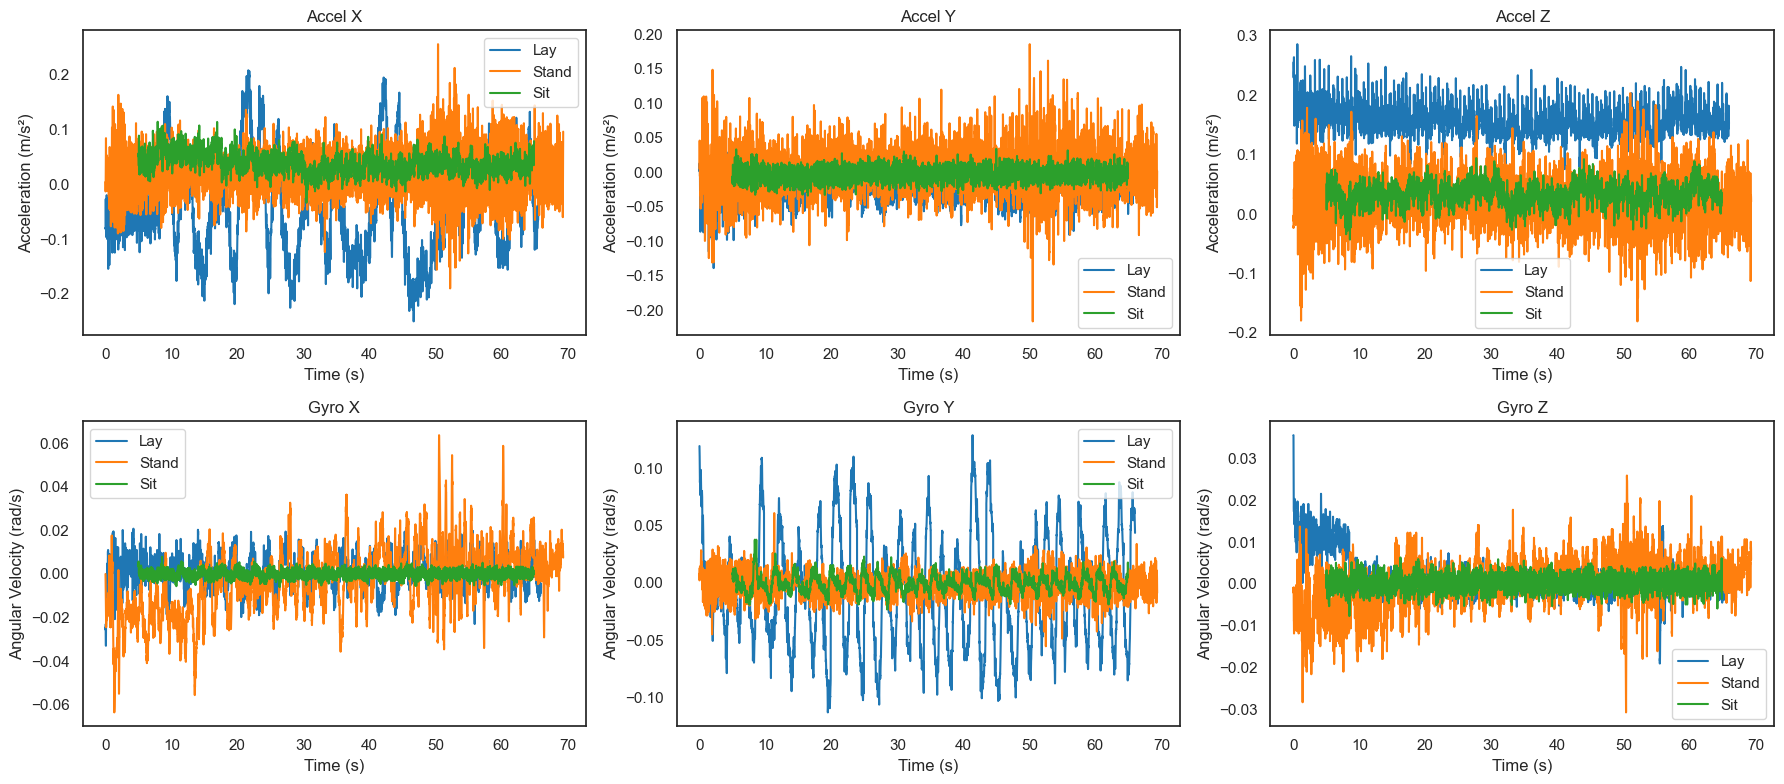

In [9]:
set_theme(style='white', palette=None)
color_pal = plt.rcParams['axes.prop_cycle'].by_key()['color']
color_cycle = cycle(plt.rcParams['axes.prop_cycle'].by_key()['color'])

# Buat figure dan axes
fig, axes = plt.subplots(2, 3, figsize=(18, 8))  # 2 baris, 3 kolom

def tabel (axe, fitur, judul, satuan):
    axe.plot(df_lay['time'], df_lay[fitur], label='Lay')
    axe.plot(df_stand['time'], df_stand[fitur], label='Stand')
    axe.plot(df_sit['time'], df_sit[fitur], label='Sit')
    axe.set_title(judul)
    axe.set_xlabel('Time (s)')
    axe.set_ylabel(satuan)
    axe.legend()

tabel (axes[0, 0], 'accel_x', 'Accel X', 'Acceleration (m/s²)')
tabel (axes[0, 1], 'accel_y', 'Accel Y', 'Acceleration (m/s²)')
tabel (axes[0, 2], 'accel_z', 'Accel Z', 'Acceleration (m/s²)')
tabel (axes[1, 0], 'gyro_x', 'Gyro X', 'Angular Velocity (rad/s)')
tabel (axes[1, 1], 'gyro_y', 'Gyro Y', 'Angular Velocity (rad/s)')
tabel (axes[1, 2], 'gyro_z', 'Gyro Z', 'Angular Velocity (rad/s)')

# Atur layout biar rapi
plt.tight_layout()

# Tampilkan plot
plt.show()

#### <u> Data 12 Sekon &#8594; Run, Walk</u>

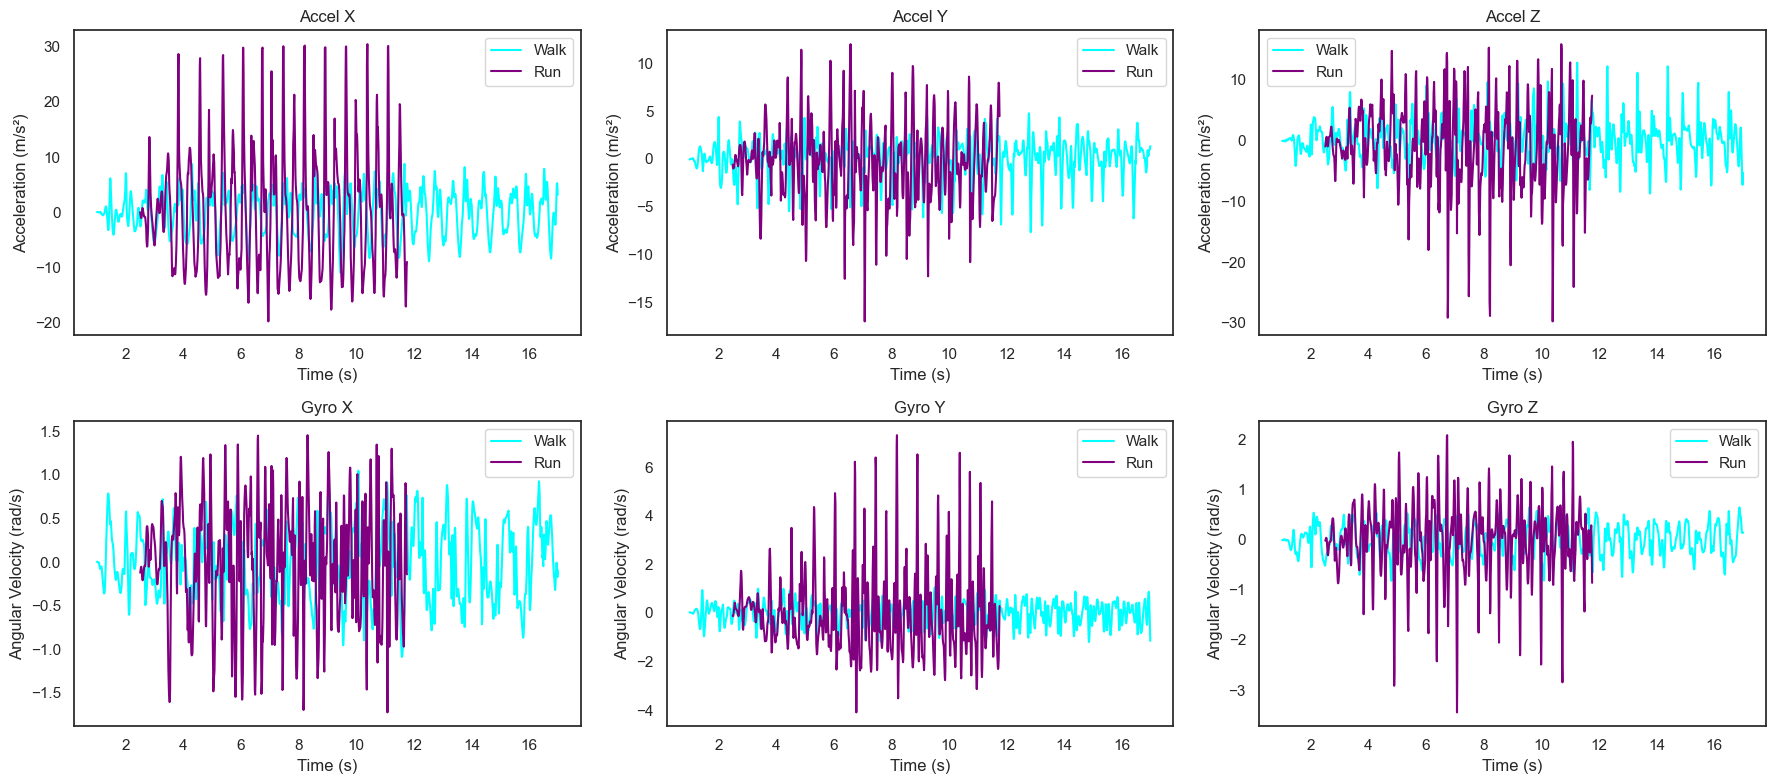

In [10]:
# Buat figure dan axes
fig, axes = plt.subplots(2, 3, figsize=(18, 8))  # 2 baris, 3 kolom

def tabel (axe, fitur, judul, satuan):
    axe.plot(df_walk['time'], df_walk[fitur], label='Walk', color="cyan")
    axe.plot(df_run['time'], df_run[fitur], label='Run', color="purple")
    axe.set_title(judul)
    axe.set_xlabel('Time (s)')
    axe.set_ylabel(satuan)
    axe.legend()

tabel (axes[0, 0], 'accel_x', 'Accel X', 'Acceleration (m/s²)')
tabel (axes[0, 1], 'accel_y', 'Accel Y', 'Acceleration (m/s²)')
tabel (axes[0, 2], 'accel_z', 'Accel Z', 'Acceleration (m/s²)')
tabel (axes[1, 0], 'gyro_x', 'Gyro X', 'Angular Velocity (rad/s)')
tabel (axes[1, 1], 'gyro_y', 'Gyro Y', 'Angular Velocity (rad/s)')
tabel (axes[1, 2], 'gyro_z', 'Gyro Z', 'Angular Velocity (rad/s)')

# Atur layout biar rapi
plt.tight_layout()

# Tampilkan plot
plt.show()

___

### <span style="font-size:20pt"><b>#3: Feature Extraction </b></span>

Feature Extraction dibutuhkan karena dalam memprediksi aktivitas tidak bisa digunakan data sesaat. Dalam rentang waktu tertentu terdapat fluktuasi data sehingga digunakan feature extraction per 3 sekon untuk stand, lay, dan sit (karena memiliki rentang data 60 sekon) serta 1 sekon untuk run dan walk (karena memiliki rentang data 12 sekon) untuk memperoleh data

- Mean
- Standar Deviation
- Max
- Min

#### <b>A. Penyusunan Fungsi Feature Extraction</b>

In [11]:
import os
import pandas as pd

# Fungsi ekstraksi fitur yang tadi sudah dibuat
def extract_features(folder_path, label, output_path, window_size=5):
    all_features = []
    
    for filename in os.listdir(folder_path):
        if filename.endswith('.csv'):
            file_path = os.path.join(folder_path, filename)

            # Baca file CSV tanpa header
            df = pd.read_csv(file_path, header=None, names=['time', 'accel_x', 'accel_y', 'accel_z', 'time2', 'gyro_x', 'gyro_y', 'gyro_z'])

            start_time = df['time'].min()
            end_time = df['time'].max()

            current_time = start_time
            while current_time < end_time:
                # Windowing per window_size detik
                window_df = df[(df['time'] >= current_time) & (df['time'] < current_time + window_size)]

                if not window_df.empty:
                    features = {
                        'mean_accel_x': window_df['accel_x'].mean(),
                        'std_accel_x': window_df['accel_x'].std(),
                        'max_accel_x': window_df['accel_x'].max(),
                        'min_accel_x': window_df['accel_x'].min(),

                        'mean_accel_y': window_df['accel_y'].mean(),
                        'std_accel_y': window_df['accel_y'].std(),
                        'max_accel_y': window_df['accel_y'].max(),
                        'min_accel_y': window_df['accel_y'].min(),

                        'mean_accel_z': window_df['accel_z'].mean(),
                        'std_accel_z': window_df['accel_z'].std(),
                        'max_accel_z': window_df['accel_z'].max(),
                        'min_accel_z': window_df['accel_z'].min(),

                        'mean_gyro_x': window_df['gyro_x'].mean(),
                        'std_gyro_x': window_df['gyro_x'].std(),
                        'max_gyro_x': window_df['gyro_x'].max(),
                        'min_gyro_x': window_df['gyro_x'].min(),

                        'mean_gyro_y': window_df['gyro_y'].mean(),
                        'std_gyro_y': window_df['gyro_y'].std(),
                        'max_gyro_y': window_df['gyro_y'].max(),
                        'min_gyro_y': window_df['gyro_y'].min(),

                        'mean_gyro_z': window_df['gyro_z'].mean(),
                        'std_gyro_z': window_df['gyro_z'].std(),
                        'max_gyro_z': window_df['gyro_z'].max(),
                        'min_gyro_z': window_df['gyro_z'].min(),

                        'label': label
                    }
                    all_features.append(features)
                current_time += window_size

    # Buat DataFrame hasil ekstraksi
    feature_df = pd.DataFrame(all_features)

    # Simpan ke CSV
    feature_df.to_csv(output_path, index=False)
    print(f"Fitur {label} selesai diekstrak dan disimpan ke {output_path}.")

#### <b>B. Feature Extraction Tiap Aktivitas</b>

Dalam hal ini, digunakan seluruh datasheet untuk memaksimalkan model

In [12]:
# Path masing-masing folder kategori
stand_folder = os.path.join(base_folder, "0.Stand")
sit_folder   = os.path.join(base_folder, "1.Sit")
lay_folder   = os.path.join(base_folder, "5.Lay")
walk_folder  = os.path.join(base_folder, "11.Walk")
run_folder   = os.path.join(base_folder, "14.Run")

# Output path (di folder script/ipynb ini)
output_dir = os.getcwd()

stand_output = os.path.join(output_dir, "stand_features.csv")
sit_output   = os.path.join(output_dir, "sit_features.csv")
lay_output   = os.path.join(output_dir, "lay_features.csv") 
walk_output  = os.path.join(output_dir, "walk_features.csv")
run_output   = os.path.join(output_dir, "run_features.csv")

# Panggil fungsi untuk masing-masing
extract_features(stand_folder, 1, stand_output, window_size=3)
extract_features(sit_folder, 2, sit_output, window_size=3)
extract_features(lay_folder, 3, lay_output, window_size=3)
extract_features(walk_folder, 4, walk_output, window_size=1)
extract_features(run_folder, 5, run_output, window_size=1)

Fitur 1 selesai diekstrak dan disimpan ke d:\Data Rapi\Waktu Nadhir di UGM\Semester 6\03. Teknologi Sensor\Project\stand_features.csv.
Fitur 2 selesai diekstrak dan disimpan ke d:\Data Rapi\Waktu Nadhir di UGM\Semester 6\03. Teknologi Sensor\Project\sit_features.csv.
Fitur 3 selesai diekstrak dan disimpan ke d:\Data Rapi\Waktu Nadhir di UGM\Semester 6\03. Teknologi Sensor\Project\lay_features.csv.
Fitur 4 selesai diekstrak dan disimpan ke d:\Data Rapi\Waktu Nadhir di UGM\Semester 6\03. Teknologi Sensor\Project\walk_features.csv.
Fitur 5 selesai diekstrak dan disimpan ke d:\Data Rapi\Waktu Nadhir di UGM\Semester 6\03. Teknologi Sensor\Project\run_features.csv.


___

### <span style="font-size:20pt"><b>#4: Data Cleaning </b></span>

#### <b>A. Import Dataframe Hasil Ekstraksi</b>

In [13]:
# Path folder tempat CSV hasil ekstraksi
output_dir = os.getcwd()

# Path masing-masing file CSV
stand_csv = os.path.join(output_dir, "stand_features.csv")
sit_csv   = os.path.join(output_dir, "sit_features.csv")
lay_csv   = os.path.join(output_dir, "lay_features.csv")
walk_csv  = os.path.join(output_dir, "walk_features.csv")
run_csv   = os.path.join(output_dir, "run_features.csv")

# Load ketiga CSV jadi DataFrame
df_stand = pd.read_csv(stand_csv)
df_sit   = pd.read_csv(sit_csv)
df_lay   = pd.read_csv(lay_csv)
df_walk  = pd.read_csv(walk_csv)
df_run   = pd.read_csv(run_csv)

# Gabungkan ketiganya
df = pd.concat([df_stand, df_sit, df_lay, df_walk, df_run], ignore_index=True)

#### <b>B. Cek Data Hilang</b>

In [14]:
# Cek jumlah NaN di tiap fitur
nan_count = df.isna().sum()

# Tampilkan hasil
print("Jumlah NaN di tiap fitur:")
print(nan_count)

Jumlah NaN di tiap fitur:
mean_accel_x    0
std_accel_x     2
max_accel_x     0
min_accel_x     0
mean_accel_y    0
std_accel_y     2
max_accel_y     0
min_accel_y     0
mean_accel_z    0
std_accel_z     2
max_accel_z     0
min_accel_z     0
mean_gyro_x     0
std_gyro_x      2
max_gyro_x      0
min_gyro_x      0
mean_gyro_y     0
std_gyro_y      2
max_gyro_y      0
min_gyro_y      0
mean_gyro_z     0
std_gyro_z      2
max_gyro_z      0
min_gyro_z      0
label           0
dtype: int64


Terdapat data hilang untuk beberapa fitur sehingga perlu dihilangkan

#### <b>B. Menghilangkan NaN</b>

In [15]:
# Drop baris yang mengandung NaN
df_clean = df.dropna()

# Cek kembali setelah di-drop
nan_count_after = df_clean.isna().sum().reset_index()
nan_count_after.columns = ['Fitur', 'Jumlah NaN']

print("\nJumlah NaN setelah di-drop:")
print(nan_count_after)

# Tampilkan jumlah data awal dan setelah di-drop
print(f"\nJumlah data sebelum di-drop: {len(df)}")
print(f"Jumlah data setelah di-drop : {len(df_clean)}")


Jumlah NaN setelah di-drop:
           Fitur  Jumlah NaN
0   mean_accel_x           0
1    std_accel_x           0
2    max_accel_x           0
3    min_accel_x           0
4   mean_accel_y           0
5    std_accel_y           0
6    max_accel_y           0
7    min_accel_y           0
8   mean_accel_z           0
9    std_accel_z           0
10   max_accel_z           0
11   min_accel_z           0
12   mean_gyro_x           0
13    std_gyro_x           0
14    max_gyro_x           0
15    min_gyro_x           0
16   mean_gyro_y           0
17    std_gyro_y           0
18    max_gyro_y           0
19    min_gyro_y           0
20   mean_gyro_z           0
21    std_gyro_z           0
22    max_gyro_z           0
23    min_gyro_z           0
24         label           0

Jumlah data sebelum di-drop: 9856
Jumlah data setelah di-drop : 9854


___

### <span style="font-size:20pt"><b>#5: Analisis Statistik </b></span>

#### <b>A. Informasi Dataframe</b>

In [16]:
df = df_clean
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9854 entries, 0 to 9855
Data columns (total 25 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mean_accel_x  9854 non-null   float64
 1   std_accel_x   9854 non-null   float64
 2   max_accel_x   9854 non-null   float64
 3   min_accel_x   9854 non-null   float64
 4   mean_accel_y  9854 non-null   float64
 5   std_accel_y   9854 non-null   float64
 6   max_accel_y   9854 non-null   float64
 7   min_accel_y   9854 non-null   float64
 8   mean_accel_z  9854 non-null   float64
 9   std_accel_z   9854 non-null   float64
 10  max_accel_z   9854 non-null   float64
 11  min_accel_z   9854 non-null   float64
 12  mean_gyro_x   9854 non-null   float64
 13  std_gyro_x    9854 non-null   float64
 14  max_gyro_x    9854 non-null   float64
 15  min_gyro_x    9854 non-null   float64
 16  mean_gyro_y   9854 non-null   float64
 17  std_gyro_y    9854 non-null   float64
 18  max_gyro_y    9854 non-null   flo

#### <b>B. Analisis Distribusi Tiap Aktivitas</b>

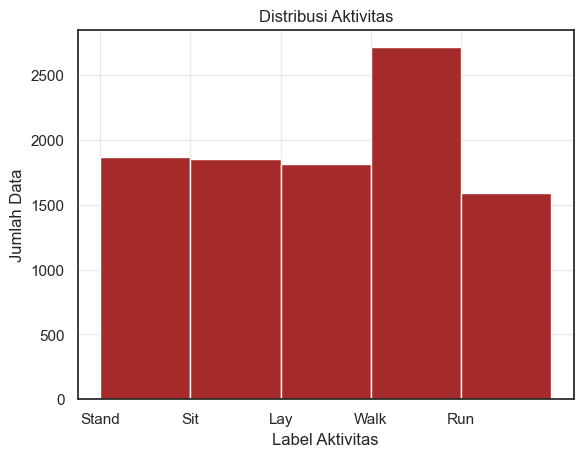

In [17]:
# Membuat histogram
plt.hist(df['label'], bins=range(1, 7), edgecolor='white', color='brown')  # Pastikan bins sesuai
plt.title('Distribusi Aktivitas')
plt.xlabel('Label Aktivitas')
plt.ylabel('Jumlah Data')

# Mengubah keterangan di sumbu x
plt.xticks(ticks=[1, 2, 3, 4, 5], labels=['Stand', 'Sit', 'Lay', 'Walk', 'Run'])

plt.grid(alpha=0.4)
plt.show()

In [18]:
# Mapping label ke nama aktivitas
label_mapping = {1: 'Stand', 2: 'Sit', 3: 'Lay', 4: 'Walk', 5: 'Run'}

# Hitung jumlah data per aktivitas
counts = df['label'].value_counts().sort_index()

# Tampilkan hasilnya
for label, count in counts.items():
    print(f"{label_mapping[label]}: {count} data")

Stand: 1872 data
Sit: 1855 data
Lay: 1816 data
Walk: 2716 data
Run: 1595 data


#### <b>C. Pengaruh Variable Input Terhadap Variabel Output</b>

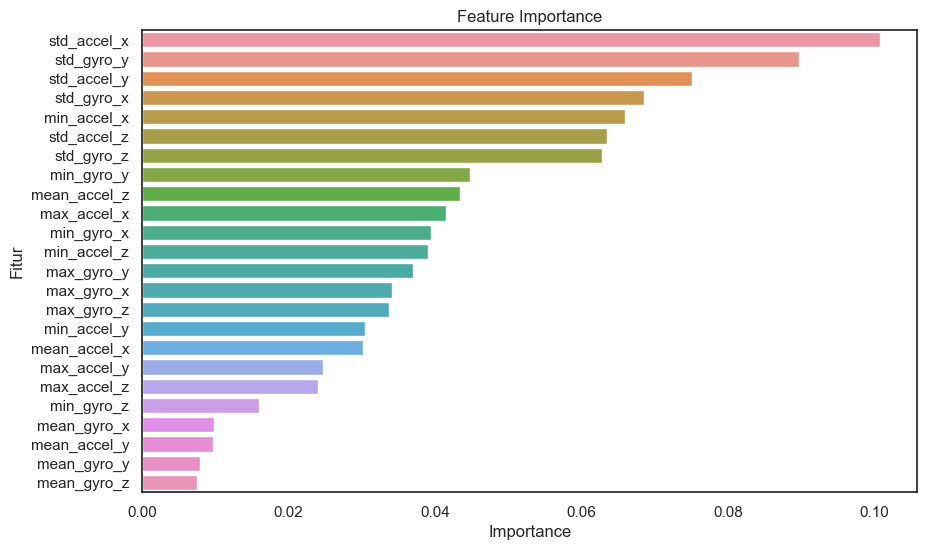

In [19]:
from sklearn.ensemble import RandomForestClassifier

# Contoh training model
X = df.drop('label', axis=1)
y = df['label']

model = RandomForestClassifier()
model.fit(X, y)

# Ambil feature importance
importances = model.feature_importances_
feature_names = X.columns

# Buat DataFrame
importance_df = pd.DataFrame({'Fitur': feature_names, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10,6))
sns.barplot(data=importance_df, x='Importance', y='Fitur')
plt.title('Feature Importance')
plt.show()

___

### <b>#5: Feature Engineering </b>

#### <u> Pembagian Data Training, Test, dan Validasi</u>

In [20]:
from sklearn.model_selection import train_test_split

# Misal X = fitur, y = label
X_trainval, X_test, y_trainval, y_test = train_test_split(X, y, test_size=0.2, random_state=42)  # 20% test
X_train, X_val, y_train, y_val = train_test_split(X_trainval, y_trainval, test_size=0.2, random_state=42)  # 20% dari sisa untuk validasi (16% dari total)

# Cek ukuran masing-masing
print(f"Train : {len(X_train)} data")
print(f"Validation : {len(X_val)} data")
print(f"Test : {len(X_test)} data")

Train : 6306 data
Validation : 1577 data
Test : 1971 data


___

### <b>#6: Model Building &#8594; Random Forest</b>

#### <u> Training Model</u>

In [21]:
from sklearn.ensemble import RandomForestClassifier

# Inisialisasi dan training model di data training
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

#### <u> Uji Performa (Data Test)</u>

In [22]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Uji Performa Data Test
y_test_pred = model.predict(X_test)

test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred, average='weighted')
test_recall = recall_score(y_test, y_test_pred, average='weighted')
test_f1 = f1_score(y_test, y_test_pred, average='weighted')

print(f"[TEST]")
print(f"Akurasi  : {test_accuracy:.2f}")
print(f"Presisi  : {test_precision:.2f}")
print(f"Recall   : {test_recall:.2f}")
print(f"F1 Score : {test_f1:.2f}")

[TEST]
Akurasi  : 0.95
Presisi  : 0.96
Recall   : 0.95
F1 Score : 0.95


#### <u> Uji Performa (Data Validasi)</u>

In [23]:
# Evaluasi di data validasi
y_val_pred = model.predict(X_val)

val_accuracy = accuracy_score(y_val, y_val_pred)
val_precision = precision_score(y_val, y_val_pred, average='weighted')
val_recall = recall_score(y_val, y_val_pred, average='weighted')
val_f1 = f1_score(y_val, y_val_pred, average='weighted')

print(f"[VALIDASI]")
print(f"Akurasi  : {val_accuracy:.2f}")
print(f"Presisi  : {val_precision:.2f}")
print(f"Recall   : {val_recall:.2f}")
print(f"F1 Score : {val_f1:.2f}")

[VALIDASI]
Akurasi  : 0.96
Presisi  : 0.96
Recall   : 0.96
F1 Score : 0.96


#### <u> Confusion Matrix</u>

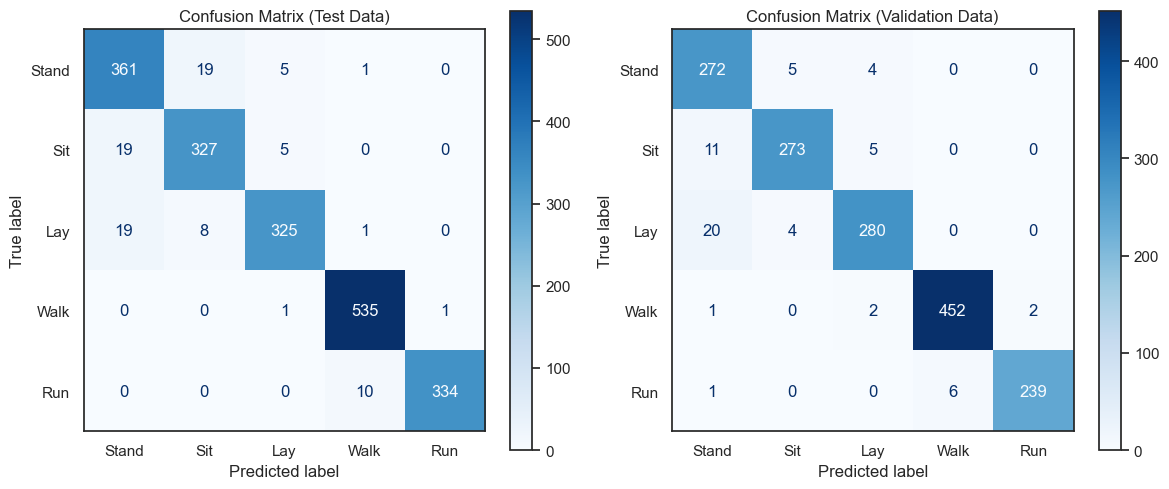

In [24]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

labels = ['Stand', 'Sit', 'Lay', 'Walk', 'Run']
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Confusion matrix test
cm_test = confusion_matrix(y_test, y_test_pred, labels=model.classes_)
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=labels)
disp_test.plot(cmap='Blues', values_format='d', ax=axes[0])
axes[0].set_title("Confusion Matrix (Test Data)")

# Confusion matrix validasi
cm_val = confusion_matrix(y_val, y_val_pred, labels=model.classes_)
disp_val = ConfusionMatrixDisplay(confusion_matrix=cm_val, display_labels=labels)
disp_val.plot(cmap='Blues', values_format='d', ax=axes[1])
axes[1].set_title("Confusion Matrix (Validation Data)")

plt.tight_layout()
plt.show()

___

### <b>#7: Model Building &#8594; KNN </b>

#### <u> Training Model</u>

In [25]:
from sklearn.neighbors import KNeighborsClassifier

# Inisialisasi dan training model di data training
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

KNeighborsClassifier()

#### <u> Uji Performa (Data Test)</u>

In [26]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Jika performa validasi oke, lanjut prediksi di data test
y_test_pred = knn.predict(X_test)

knn_test_accuracy = accuracy_score(y_test, y_test_pred)
knn_test_precision = precision_score(y_test, y_test_pred, average='weighted')
knn_test_recall = recall_score(y_test, y_test_pred, average='weighted')
knn_test_f1 = f1_score(y_test, y_test_pred, average='weighted')

print(f"[TEST]")
print(f"Akurasi  : {knn_test_accuracy:.2f}")
print(f"Presisi  : {knn_test_precision:.2f}")
print(f"Recall   : {knn_test_recall:.2f}")
print(f"F1 Score : {knn_test_f1:.2f}")

[TEST]
Akurasi  : 0.91
Presisi  : 0.91
Recall   : 0.91
F1 Score : 0.91


#### <u> Uji Performa (Data Validasi)</u>

In [27]:
# Evaluasi di data validasi
y_val_pred = knn.predict(X_val)

knn_val_accuracy = accuracy_score(y_val, y_val_pred)
knn_val_precision = precision_score(y_val, y_val_pred, average='weighted')
knn_val_recall = recall_score(y_val, y_val_pred, average='weighted')
knn_val_f1 = f1_score(y_val, y_val_pred, average='weighted')

print(f"[VALIDASI]")
print(f"Akurasi  : {knn_val_accuracy:.2f}")
print(f"Presisi  : {knn_val_precision:.2f}")
print(f"Recall   : {knn_val_recall:.2f}")
print(f"F1 Score : {knn_val_f1:.2f}")

[VALIDASI]
Akurasi  : 0.91
Presisi  : 0.91
Recall   : 0.91
F1 Score : 0.91


#### <u> Confusion Matrix</u>

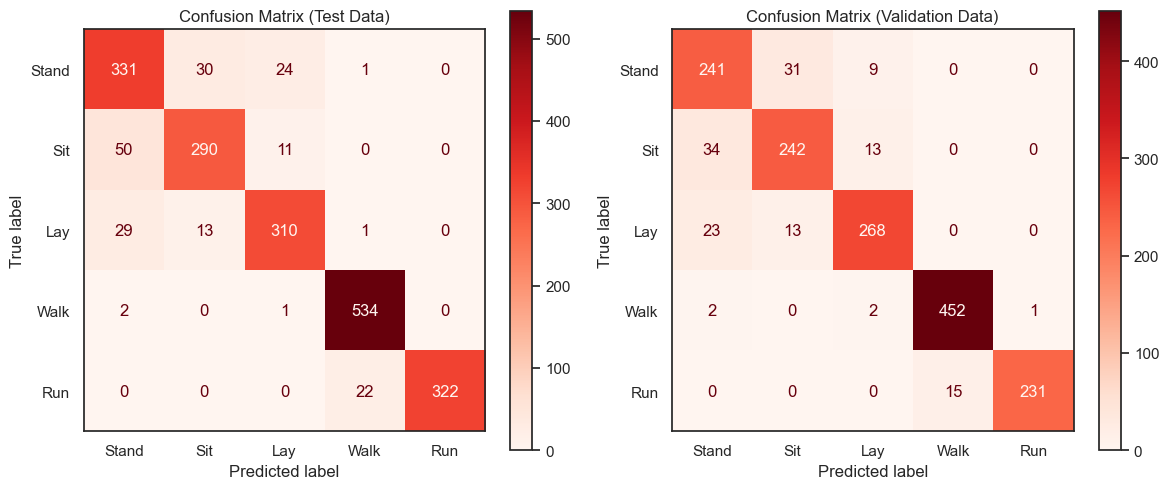

In [28]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Confusion matrix test
cm_test = confusion_matrix(y_test, y_test_pred, labels=model.classes_)
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=labels)
disp_test.plot(cmap='Reds', values_format='d', ax=axes[0])
axes[0].set_title("Confusion Matrix (Test Data)")

# Confusion matrix validasi
cm_val = confusion_matrix(y_val, y_val_pred, labels=model.classes_)
disp_val = ConfusionMatrixDisplay(confusion_matrix=cm_val, display_labels=labels)
disp_val.plot(cmap='Reds', values_format='d', ax=axes[1])
axes[1].set_title("Confusion Matrix (Validation Data)")

plt.tight_layout()
plt.show()

___

### <b>#8: Evaluasi Model </b>

In [29]:
evaluasi = {
    'Metriks' : ['Akurasi', 'Presisi', 'Recall', 'F1 Score'],
    'RF - Test' : [test_accuracy, test_precision, test_recall, test_f1],
    'RF - Validasi' : [val_accuracy, val_precision, val_recall, val_f1],
    'KNN - Test' : [knn_test_accuracy, knn_test_precision, knn_test_recall, knn_test_f1],
    'KNN - Validasi' : [knn_val_accuracy, knn_val_precision, knn_val_recall, knn_val_f1]
}

evaluasi_df = pd.DataFrame(evaluasi)
evaluasi_df

,Metriks,RF - Test,RF - Validasi,KNN - Test,KNN - Validasi
0,Akurasi,0.954845,0.961319,0.906646,0.909321
1,Presisi,0.955405,0.962494,0.908149,0.910938
2,Recall,0.954845,0.961319,0.906646,0.909321
3,F1 Score,0.954917,0.961499,0.906822,0.909734
